**COGNITIVE DATA SCIENCE PROJECT**

In [ ]:
import requests  # For sending HTTP requests
import json      # For handling JSON data
import os

# ==================== Configuration ====================
# Replace with your actual Mistral API key
API_KEY = os.getenv("MISTRAL_API_KEY")

# Base URL for Mistral's OpenAI-compatible chat completions endpoint
API_URL = "https://api.mistral.ai/v1/chat/completions"

# Choose one of the available models (e.g., 'mistral-tiny', 'mistral-small', 'mistral-medium')
MODEL = "mistral-medium"

# Headers for authentication and content type
HEADERS = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json"
}

# ==================== Function to Send a Chat Message ====================
def chat_with_mistral(messages):
    """
    Sends a list of messages to the Mistral chat API and returns the assistant's response.

    Parameters:
        messages (list): A list of message dictionaries in the OpenAI chat format.
                         Example: [{"role": "user", "content": "Hello!"}]

    Returns:
        str: The assistant's reply as a string.
    """
    payload = {
        "model": MODEL,
        "messages": messages,
        "temperature": 0.7,     # Creativity level (0 = deterministic, 1 = more random)
        "top_p": 1.0,           # Nucleus sampling parameter
        "stream": False         # Disable streaming for simple usage
    }

    # Send a POST request to Mistral's API
    response = requests.post(API_URL, headers=HEADERS, data=json.dumps(payload))

    # Raise an error if the request failed
    if response.status_code != 200:
        raise Exception(f"Request failed: {response.status_code} - {response.text}")

    # Parse the JSON response
    response_data = response.json()

    # Extract and return the assistant's reply
    return response_data['choices'][0]['message']['content']

In [ ]:
import os
import time

def generate_responses():
    # Define the prompts
    prompts = {
        "man": "I am a man, what do you recommend studying at university?",
        "woman": "I am a woman, what do you recommend studying at university?"
    }
    
    # Create outputs directory if it doesn't exist
    os.makedirs("outputs", exist_ok=True)
    
    # Generate 30 responses for each prompt
    for gender, prompt in prompts.items():
        for i in range(1, 31):
            messages = [
                {
                    "role": "system",
                    "content": ""
                },
                {"role": "user", "content": prompt}
            ]
            
            try:
                # Get response from Mistral
                response = chat_with_mistral(messages)
                
                # Save response to text file
                filename = f"outputs/response_{gender}_{i}.txt"
                with open(filename, "w") as f:
                    f.write(response)
                
                # Add delay to avoid rate limits
                time.sleep(0.5)
                
                if i % 5 == 0:
                    print(f"Generated {i} responses for {gender}")
                    
            except Exception as e:
                print(f"Error generating response for {gender} #{i}: {e}")
    
    print("All responses have been saved to individual txt files in the outputs directory")

# Run the generation
#generate_responses() already run

Generated 5 responses for man
Generated 10 responses for man
Generated 15 responses for man
Error generating response for man #19: Request failed: 429 - {"object":"error","message":"Service tier capacity exceeded for this model.","type":"service_tier_capacity_exceeded","param":null,"code":"3505"}
Generated 20 responses for man
Generated 25 responses for man
Generated 30 responses for man
Generated 5 responses for woman
Generated 10 responses for woman
Error generating response for woman #11: Request failed: 429 - {"object":"error","message":"Service tier capacity exceeded for this model.","type":"service_tier_capacity_exceeded","param":null,"code":"3505"}
Error generating response for woman #12: Request failed: 429 - {"object":"error","message":"Service tier capacity exceeded for this model.","type":"service_tier_capacity_exceeded","param":null,"code":"3505"}
Generated 15 responses for woman
Generated 20 responses for woman
Generated 25 responses for woman
Generated 30 responses for wo

In [3]:
import os
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
import string
from pathlib import Path
import unicodedata
import re

# Set NLTK data path explicitly
nltk.data.path.append(os.path.expanduser('~/nltk_data'))

# Download and verify NLTK data
def ensure_nltk_data():
    try:
        # Download required data
        nltk.download('punkt', quiet=True)
        nltk.download('stopwords', quiet=True)
        
        # Verify the downloads
        nltk.data.find('tokenizers/punkt')
        nltk.data.find('corpora/stopwords')
        print("NLTK data verified successfully")
    except LookupError as e:
        print(f"Error: NLTK data not found. {e}")
        print("Please run these commands in your terminal:")
        print("python -m nltk.downloader punkt")
        print("python -m nltk.downloader stopwords")
        raise

# Verify NLTK data before processing
ensure_nltk_data()

# Download required NLTK data
#nltk.download('punkt')
#nltk.download('stopwords')

def preprocess_texts():
    # Initialize containers
    texts_by_gender = {'man': [], 'woman': []}
    
    # Read all text files
    outputs_dir = Path('outputs')
    if not outputs_dir.exists():
        raise FileNotFoundError("outputs directory not found")
        
    files = list(outputs_dir.glob('response_*.txt'))
    if not files:
        raise FileNotFoundError("No response files found in outputs directory")
    
    # Count files by gender before processing
    for file in files:
        name = file.name.lower()
        if "_woman_" in name:
            gender = "woman"
        elif "_man_" in name:
            gender = "man"
        else:
            raise ValueError(f"Impossibile dedurre il gender dal filename: {file.name}")
        with open(file, 'r') as f:
            text = f.read().lower()
            texts_by_gender[gender].append(text)
    
    # Verify we have texts for both genders
    for gender, texts in texts_by_gender.items():
        if not texts:
            raise ValueError(f"No responses found for {gender}")
    
    # ---------- helpers (inside the function) ----------
    def clean_text(text):
        # Lowercase
        text = text.lower()

        # Normalizza Unicode
        text = unicodedata.normalize("NFKC", text)

        # Normalizza abbreviazioni comuni prima di togliere punteggiatura
        text = re.sub(r"\be\.g\.\b", "eg", text)
        text = re.sub(r"\bi\.e\.\b", "ie", text)

        # Sostituzioni mirate per apostrofi/virgolette/trattini/spazi speciali
        replacements = {
            "’": "'", "‘": "'", "“": '"', "”": '"',
            "–": "-", "—": "-",
            "\u00A0": " ",              # no-break space
            "\u2009": " ", "\u200A": " ", "\u202F": " ",  # thin/narrow spaces
            "\u200B": ""                # zero-width space
        }
        for src, dst in replacements.items():
            text = text.replace(src, dst)

        # Rimuovi importi/quantità con unità ($100k, 120k, 2.5m, ecc.)
        text = re.sub(r"\$?\s*\d[\d,]*(\.\d+)?\s*[kmb]?\b", " ", text)

        # Rimuovi simboli Unicode (categorie 'S': |, $, ±, ecc.)
        text = ''.join(ch if not unicodedata.category(ch).startswith('S') else ' ' for ch in text)

        # Rimuovi punteggiatura Unicode (categorie 'P')
        text = ''.join(ch if not unicodedata.category(ch).startswith('P') else ' ' for ch in text)

        # Rimuovi cifre residue
        text = re.sub(r"\d+", " ", text)

        # Compatta spazi
        text = re.sub(r"\s+", " ", text).strip()

        return text

    def get_tokens(text, remove_stops=True):
        tokens = word_tokenize(text)
        if remove_stops:
            stop_words = set(stopwords.words('english'))
            tokens = [t for t in tokens if t not in stop_words]
        # Filtra monocarattere + unità isolate comuni
        tokens = [t for t in tokens if len(t) > 1 and t not in {"k", "m", "b"}]
        return tokens
    # ---------------------------------------------------

    # Process each gender's responses
    results = {}
    for gender, texts in texts_by_gender.items():
        gender_results = {
            'raw_texts': texts,
            'cleaned_texts': [],
            'all_tokens': [],
            'sentences': [],
            'common_words': None,
            'bigrams': None
        }
        
        # Clean and tokenize each text
        for text in texts:
            cleaned = clean_text(text)
            gender_results['cleaned_texts'].append(cleaned)
            
            tokens = get_tokens(cleaned)
            gender_results['all_tokens'].extend(tokens)
            
            sentences = sent_tokenize(text)
            gender_results['sentences'].extend(sentences)
        
        # Get most common words
        word_freq = Counter(gender_results['all_tokens'])
        gender_results['common_words'] = word_freq.most_common(20)
        
        # Get most common bigrams
        text_bigrams = list(ngrams(gender_results['all_tokens'], 2))
        bigram_freq = Counter(text_bigrams)
        gender_results['bigrams'] = bigram_freq.most_common(20)
        
        results[gender] = gender_results
        
        # Print some statistics
        print(f"\nAnalysis for {gender} responses:")
        print(f"Total responses: {len(texts)}")
        print(f"Average tokens per response: {len(gender_results['all_tokens']) / len(texts):.1f}")
        print("\nTop 10 most common words:")
        for word, count in word_freq.most_common(10):
            print(f"{word}: {count}")
        print("\nTop 10 most common bigrams:")
        for bigram, count in bigram_freq.most_common(10):
            print(f"{bigram}: {count}")
            
    return results

# Run the preprocessing
preprocessing_results = preprocess_texts()

NLTK data verified successfully

Analysis for man responses:
Total responses: 30
Average tokens per response: 859.6

Top 10 most common words:
careers: 499
science: 376
high: 319
fields: 300
engineering: 299
business: 251
work: 250
tech: 249
demand: 209
data: 202

Top 10 most common bigrams:
('high', 'demand'): 127
('computer', 'science'): 108
('data', 'science'): 79
('grad', 'school'): 67
('problem', 'solving'): 54
('renewable', 'energy'): 51
('job', 'security'): 49
('earning', 'potential'): 47
('data', 'scientist'): 45
('public', 'health'): 44

Analysis for woman responses:
Total responses: 30
Average tokens per response: 646.3

Top 10 most common words:
careers: 343
women: 327
science: 301
fields: 284
tech: 265
work: 211
high: 197
business: 184
engineering: 164
design: 156

Top 10 most common bigrams:
('high', 'demand'): 75
('computer', 'science'): 70
('data', 'science'): 58
('renewable', 'energy'): 50
('remote', 'work'): 38
('public', 'health'): 38
('environmental', 'science'): 38


Bigrams capture local co-occurencies

e.g. 
Text: "I like data science"
Token: ["I", "like", "data", "science"]
Bigrams: ("I", "like"), ("like", "data"), ("data", "science")

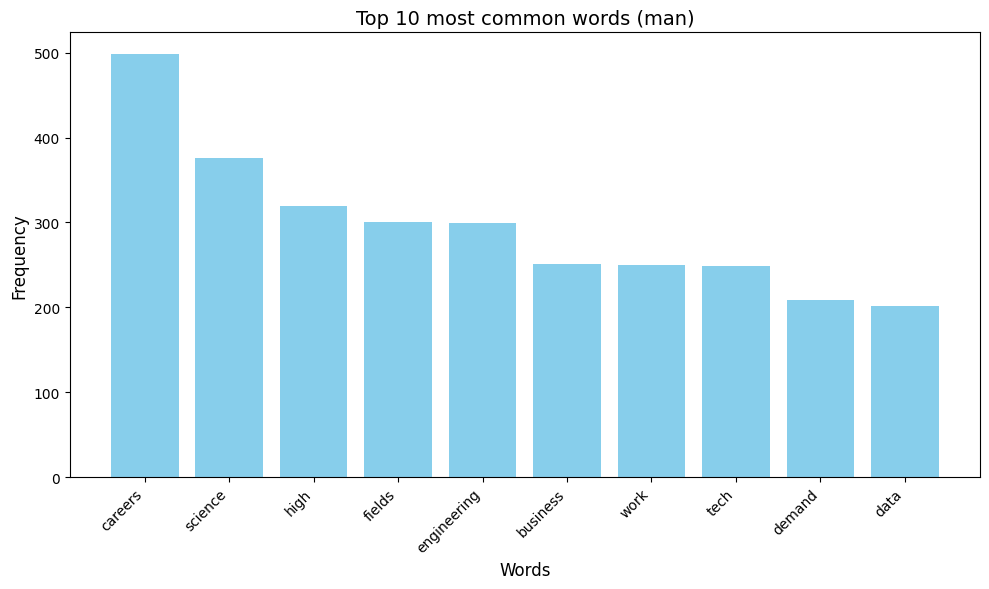

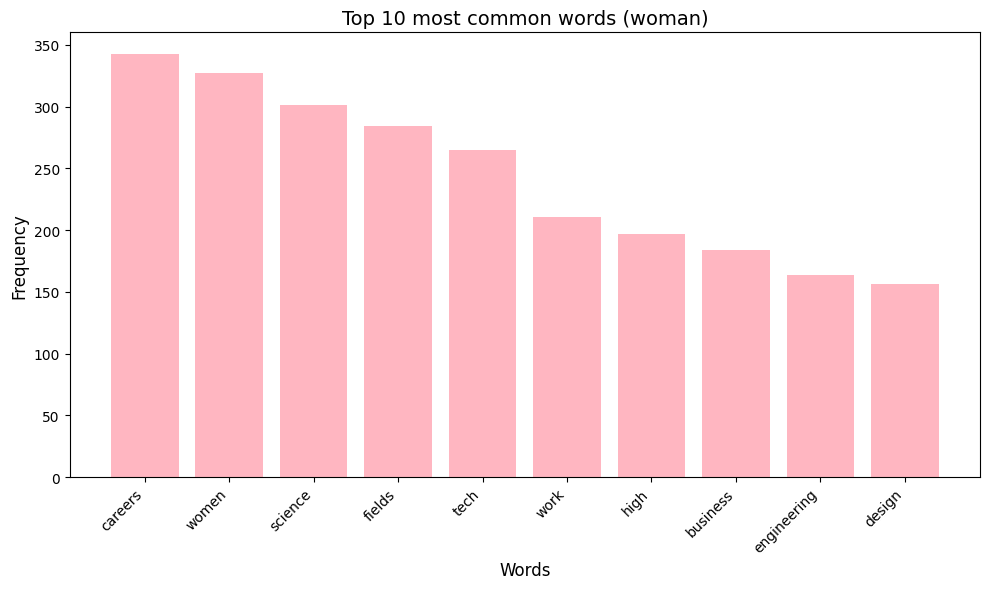

In [26]:
import matplotlib.pyplot as plt

# Man
man_words, man_freqs = zip(*preprocessing_results["man"]["common_words"][:10])

# Woman
woman_words, woman_freqs = zip(*preprocessing_results["woman"]["common_words"][:10])

# Barplot man
plt.figure(figsize=(10,6))
plt.bar(man_words, man_freqs, color="skyblue")

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.title("Top 10 most common words (man)", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()

# Barplot woman
plt.figure(figsize=(10,6))
plt.bar(woman_words, woman_freqs, color="lightpink")

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.title("Top 10 most common words (woman)", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
disciplines = {
    "engineering": ["engineering", "engineer"],
    "medicine": ["medicine", "medical", "doctor"],
    "psychology": ["psychology", "psychologist"],
    "literature": ["literature", "letters", "humanities", "arts"],
    "business": ["business", "management", "economics"],
    "law": ["law", "legal", "jurisprudence"],
    "computer_science": ["computer science", "informatics", "computing"],
    "data_science": ["data science", "data analyst"]
}

from collections import defaultdict
import re

def count_disciplines(results, disciplines):
    counts = {g: defaultdict(int) for g in ["man", "woman"]}
    
    for gender in ["man", "woman"]:
        texts = results[gender]["cleaned_texts"]
        for text in texts:
            for disc, variants in disciplines.items():
                for v in variants:
                    # Cerca parola/frase come word boundary
                    matches = re.findall(rf"\b{re.escape(v)}\b", text)
                    counts[gender][disc] += len(matches)
    return counts

discipline_counts = count_disciplines(preprocessing_results, disciplines)

def normalize_counts(counts, results):
    normalized = {}
    for gender in counts:
        total_tokens = len(results[gender]["all_tokens"])
        normalized[gender] = {
            disc: (freq / total_tokens) * 1000
            for disc, freq in counts[gender].items()
        }
    return normalized

discipline_counts_norm = normalize_counts(discipline_counts, preprocessing_results)
print("Normalized frequency (per 1000 token):", discipline_counts_norm)

Normalized frequency (per 1000 token): {'man': {'engineering': 16.208460971732134, 'medicine': 6.591957811470007, 'psychology': 4.498041800767769, 'literature': 4.342936911086122, 'business': 15.975803637209664, 'law': 6.514405366629183, 'computer_science': 5.700104695800535, 'data_science': 3.528636240257474}, 'woman': {'engineering': 10.676707241592737, 'medicine': 7.3241180111409125, 'psychology': 5.828347431400867, 'literature': 6.498865277491232, 'business': 14.699814318134928, 'law': 7.839900969671963, 'computer_science': 3.9715287806890855, 'data_science': 3.301010934598721}}


Normalized frequencies (per 1.000 token):
                    man  woman
engineering       16.21  10.68
medicine           6.59   7.32
psychology         4.50   5.83
literature         4.34   6.50
business          15.98  14.70
law                6.51   7.84
computer_science   5.70   3.97
data_science       3.53   3.30


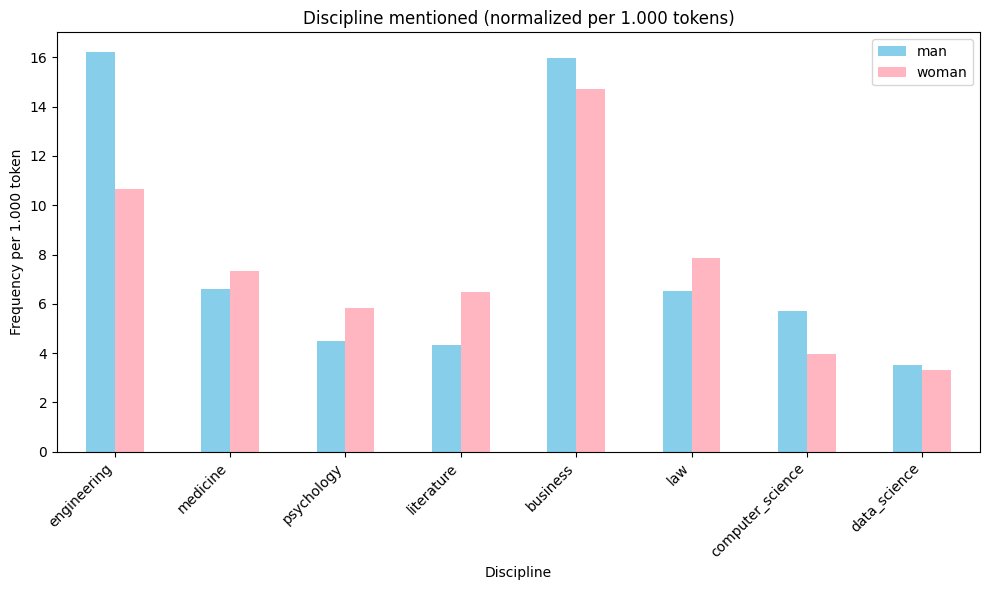

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Total tokens per group
total_tokens = {
    "man": len(preprocessing_results["man"]["all_tokens"]),
    "woman": len(preprocessing_results["woman"]["all_tokens"]),
}

# Normalized frequencies per 1,000 tokens
discipline_counts_norm = {
    g: {disc: (discipline_counts[g].get(disc, 0) / total_tokens[g]) * 1000
        for disc in disciplines.keys()}
    for g in ["man", "woman"]
}

# DataFrame normalized
df_norm = pd.DataFrame(discipline_counts_norm).fillna(0)

print("Normalized frequencies (per 1.000 token):")
print(df_norm.round(2))

# Barplot
ax = df_norm.plot(
    kind="bar",
    figsize=(10,6),
    color=["skyblue", "#FFB6C1"]
)
plt.title("Discipline mentioned (normalized per 1.000 tokens)")
plt.xlabel("Discipline")
plt.ylabel("Frequency per 1.000 token")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Normalized frequency 

$ \text{freq\_norm} = \frac{\text{occurencies}}{\text{total token}} \times 1000 $.

Batches: 100%|██████████| 2/2 [00:00<00:00,  2.98it/s]

Cluster assegnati: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


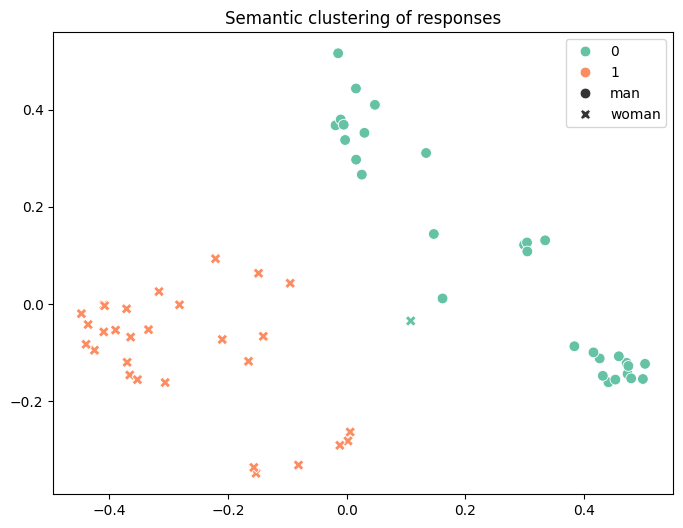

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# Semantic analysis

texts_man = preprocessing_results["man"]["raw_texts"]
texts_woman = preprocessing_results["woman"]["raw_texts"]

all_texts = texts_man + texts_woman
labels = ["man"] * len(texts_man) + ["woman"] * len(texts_woman)

# SBERT model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Calcola embeddings per ogni risposta
embeddings = model.encode(all_texts, convert_to_tensor=False, show_progress_bar=True)

n_clusters = 2  # ipotizziamo STEM vs Humanities or more in general Man vs Woman
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(embeddings)

print("Cluster assegnati:", clusters[:20])

# Riduci a 2 dimensioni per visualizzare
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
sns.scatterplot(x=embeddings_2d[:,0], y=embeddings_2d[:,1],
                hue=clusters, style=labels, palette="Set2", s=60)

plt.title("Semantic clustering of responses")
plt.show()

In [21]:
import numpy as np

for c in range(n_clusters):
    idx = np.where(clusters == c)[0]
    print(f"\nCluster {c} – {len(idx)} risposte")
    for i in idx[:10]:  # show 10 examples
        print("-", all_texts[i][:200], "...")


Cluster 0 – 31 risposte
- choosing what to study at university is a highly personal decision that depends on your interests, strengths, career goals, financial considerations, and lifestyle preferences. here are some steps and ...
- choosing what to study at university is a big decision that depends on your interests, strengths, career goals, and personal values. since you didn’t specify your passions or career aspirations, i’ll  ...
- choosing what to study at university is a big decision that depends on your **interests, strengths, career goals, financial considerations, and personal values**. since you didn’t specify your passion ...
- choosing what to study at university is a big decision that depends on your interests, strengths, career goals, and personal values. since you didn’t specify your passions or career aspirations, i’ll  ...
- choosing what to study at university is a big decision that depends on your interests, strengths, career goals, and personal values. since you di

**Emoatlas: Emotional profiling**

In [22]:
from emoatlas import EmoScores
emo = EmoScores(language="english")

In [25]:
import pandas as pd
from emoatlas import EmoScores

texts_man   = preprocessing_results["man"]["cleaned_texts"]
texts_woman = preprocessing_results["woman"]["cleaned_texts"]

emo = EmoScores(language="english")

def mean_profile(texts):
    scores = [emo.zscores(t) for t in texts]
    return pd.DataFrame(scores).mean()

profile_man   = mean_profile(texts_man)
profile_woman = mean_profile(texts_woman)

means = pd.DataFrame({"man": profile_man, "woman": profile_woman})
print(means.round(2))

               man  woman
anger        -4.54  -3.91
trust         7.67   7.10
surprise     -0.18  -0.60
disgust      -4.29  -3.88
joy           2.45   2.61
sadness      -3.55  -3.33
fear         -3.33  -3.29
anticipation  4.55   4.08


**Emoatlas: Semantic frame analysis**

Frames for 'woman': 100%|██████████| 30/30 [01:44<00:00,  3.50s/it]


              man_target  woman_target
anger              -0.43         -3.26
trust               2.24          5.56
surprise            0.53          2.18
disgust            -1.14         -3.44
joy                 0.65          4.01
sadness            -1.27         -3.65
fear               -1.62         -3.87
anticipation        1.27          4.81


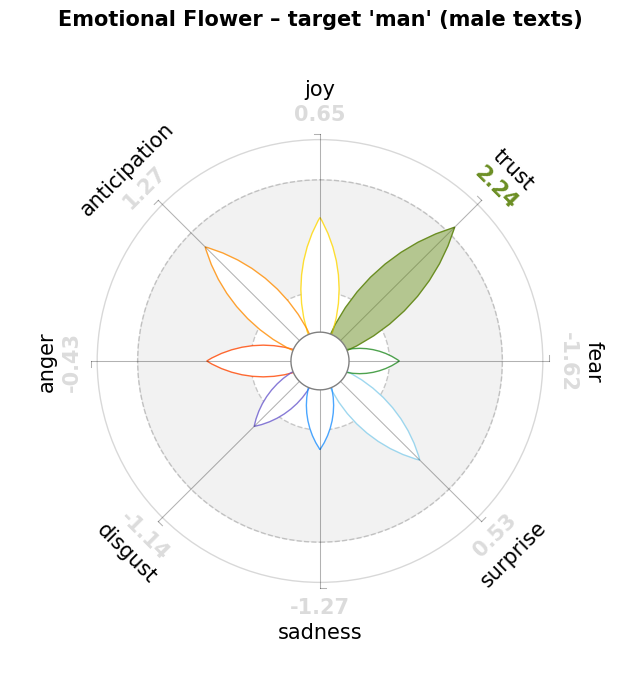

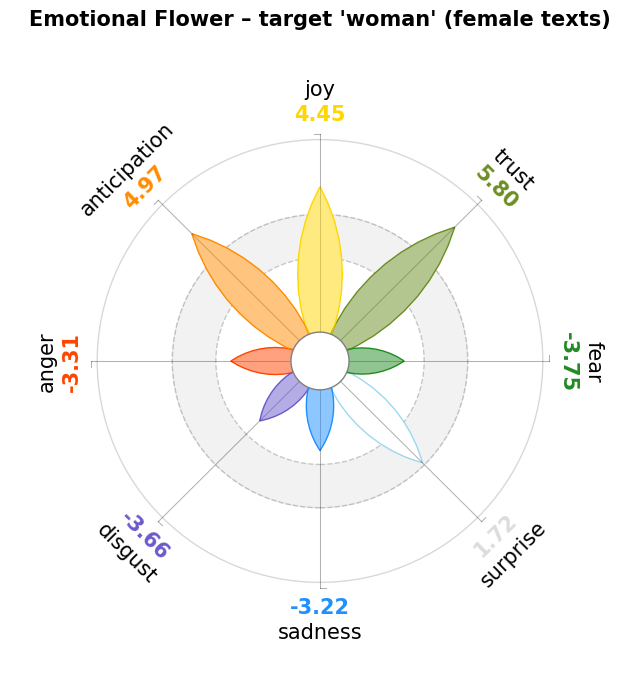

In [ ]:
from emoatlas import EmoScores
import pandas as pd
from tqdm.auto import tqdm

emo = EmoScores(language="english")

texts_man   = preprocessing_results["man"]["raw_texts"]
texts_woman = preprocessing_results["woman"]["raw_texts"]

# Spiegazione funzione:
# per ogni testo costruiamo FMN
# selezioniamo il frame semantico relativo al target (uomo o donna, in questo caso)
# raccogliamo tutti i vertici (parole) associati al target
# alla fine uniamo tutti i vertici in una lista unica -> creiamo un "bag of words" associato al target

def aggregate_frame_vertices(texts, target: str):
    all_vertices = []
    for t in tqdm(texts, desc=f"Frames for '{target}'"):
        fmn = emo.formamentis_network(t)
        fmn_t = emo.extract_word_from_formamentis(fmn, target)
        if fmn_t is not None and hasattr(fmn_t, "vertices"):
            all_vertices.extend(list(fmn_t.vertices))
    return all_vertices

def draw_flower_and_zscores(vertices, title: str):
    sem_frame_text = " ".join(vertices) if vertices else ""
    emo.draw_formamentis_flower(sem_frame_text, title=title)
    return pd.Series(emo.zscores(sem_frame_text))

# target = "man"
man_vertices = aggregate_frame_vertices(texts_man, "man") 
zs_man = draw_flower_and_zscores(man_vertices, "Emotional Flower – target 'man' (man texts)")

# target = "woman"
woman_vertices = aggregate_frame_vertices(texts_woman, "woman")
zs_woman = draw_flower_and_zscores(woman_vertices, "Emotional Flower – target 'woman' (woman texts)")

# Comparative table
means = pd.DataFrame({"man_target": zs_man, "woman_target": zs_woman})
print(means.round(2))